### Import everything

In [1]:
# PLOTTING IMPORTS

import matplotlib.pyplot as plt
import matplotlib
#plotting
kitsune   = '#D9972F'
seiheki   = '#478384'
shuan     = '#740A00'
aonibi      = '#324356'
shion       = '#968ABD'
matplotlib.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r"\usepackage{bm} \usepackage{amsmath}"
colors = ['#9e1b1b','#6cb6c4',kitsune,'#a152d9','#0b3e45','#46b52b','#787575']
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=colors)
plt.rcParams['lines.linewidth'] = 3.0
plt.rcParams['axes.linewidth'] = 2.

%matplotlib inline
%load_ext autoreload
%autoreload 2


In [2]:
import sys
import os 

sys.path.append(os.path.abspath("")+'/../scripts/')

import numpy as np
import scipy.signal.windows as windows

from meer21cm.grid import shot_noise_correction_from_gridding
from meer21cm.plot import plot_map
from meer21cm.power import bin_3d_to_1d, bin_3d_to_cy, get_shot_noise_galaxy, get_modelpk_conv


### Import the quantities from the survey_configuration file!!


This includes the inputs and the process of those inputs

In [9]:
from set_inputs import *
from sim_Pk import *
from utils import *

### Obtain the simulation power spectra!

This step is supposed to be run N times (N~500) so that we can obtain a good estimate for the ensemble averaged power spectrum to compare to the model and also estimate the covariance. Here we will make it only fifty times so that we can run it fast. Easy to parallelize, see e.g., [this script](https://github.com/meerklass/bao-systematics-task/blob/main/scripts/power_spectra.py) from Sefa for a very similar function

In [10]:
# select seed
seed0 = 123
Nrealizations = 50
rng = np.random.default_rng(seed0)
seed = rng.integers(0,12345,Nrealizations)

In [15]:
kmode, p3d_hi, p3d_x, p3d_gal = [] , [], [], []

for i in range(len(seed)):
    print(i)
    kmode_i, p3d_hi_i, p3d_x_i, p3d_gal_i = run_realization_Pks(dict(z_max=0.66, seed=seed[i]), default_dict)
    kmode.append(kmode_i)
    p3d_hi.append(p3d_hi_i)
    p3d_x.append(p3d_x_i)
    p3d_gal.append(p3d_gal_i)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49


From our N realizations, we have to first bin and then average, so first we will run the model. One thing you can do is save the N realizations so that you don't need to run them again

### Run the model

In [19]:
ps, dic = set_meer21cm(input_dict = dict(z_max=0.66), default_dict = default_dict)

In [20]:
# Apply gridding scheme, tapering, weights and trimming
ps.grid_scheme = "cic"
ps.taper_function = getattr(windows, dic['window_name'])

num_gal = int(ps.survey_volume * dic['ngal'])
ps.num_discrete_source = num_gal

#ps.W_HI = np.ones_like(ps.W_HI)
#ps.w_HI = np.ones_like(ps.w_HI)

ps.trim_map_to_range()
# ps.trim_gal_to_range() # Returns error: AttributeError: 'PowerSpectrum' object has no attribute '_ra_gal'

ps.downres_factor_transverse = 3
ps.downres_factor_radial = 6
ps.get_enclosing_box()
dndz_box = ps.discrete_source_dndz(ps._box_voxel_redshift)

ps.weights_1 = ps.counts_in_box.astype('float')
ps.apply_taper_to_field(1, axis=[0, 1, 2])
ps.weights_field_2 = dndz_box #* ps.w_HI
ps.weights_grid_2 = ((dndz_box>0)*ps.counts_in_box).astype('float') # test
ps.apply_taper_to_field(2, axis=[0, 1, 2])

ps.include_sky_sampling = [True, False]
ps.compensate = [True, True]
ps.include_beam = [True, False]

In [21]:
# Get a transfer for the beam, pixelization and gridding
beam = ps.beam_attenuation()

ps.sampling_resol = [
    ps.pix_resol_in_mpc,
    ps.pix_resol_in_mpc,
    ps.los_resol_in_mpc,
]
pix = ps.map_sampling()

grid = ps.gridding_compensation()

#Transfer square for the model power spectrum, including the mean HI temperature in case you want to use them separately
T2_x = grid**2 * pix * beam
T2_gal = grid**2 
T2_HI = (grid * pix * beam)**2 


In [22]:
Pk_HI_3D_model = ps.auto_power_tracer_1_model
Pk_HIxgal_3D_model = ps.cross_power_tracer_model
Pk_gal_3D_model = ps.auto_power_tracer_2_model

### Average the 3D power spectra in cylindrical power spectra

In [38]:
##########
# k bins #
##########
#
kmin, kmax = 0.003, 0.25                    # Minimum and maximum k values for the 1D power spectrum 
nk = 11                                     # Number of k bins for the 1D power spectrum
kmax_par, kmax_perp = 0.25, 0.05            # Maximum k values for the parallel and perpendicular directions
nk_par, nk_perp = 18, 11                    # Number of k bins for the parallel and perpendicular k values

k1d_bins = np.linspace(kmin, kmax, nk+1)[1:]
kperp_bins = np.linspace(0, kmax_perp, nk_perp+2)[2:]
kpar_bins = np.linspace(0, kmax_par, nk_par)[1:]

In [39]:
# Get the k modes from the survey
kperp = ps.k_perp
kpar = ps.k_para
kmode = ps.kmode
kvec = ps.k_vec
# and mask those that are beyond your limits (in form of weights)
kperp_limit = 0.05
kpar_limit = 0.2

k_xy_sel = (
    (np.abs(kvec[0])<kperp_limit)[:,None,None] 
    * (np.abs(kvec[1])<kperp_limit)[None,:,None]
    * (np.abs(kvec[2])<kpar_limit)[None,None,:]
)
k_xy_sel[0] = 0.0
k_xy_sel[:,0] = 0.0
k_xy_sel[:,:,0] = 0.0
k_cy_sel = np.ones_like(k_xy_sel)
k_cy_sel[0] = 0.0
k_cy_sel[:,0] = 0.0
k_cy_sel[:,:,0] = 0.0



In [40]:
#Model power spectra

Pk_HI_2D_model = bin_power_cy((Pk_HI_3D_model)[None],
    kperp,
    kpar,
    kperp_bins,
    kpar_bins,
    kweights=k_cy_sel,
)[0]

Pk_HIxgal_2D_model = bin_power_cy((Pk_HIxgal_3D_model)[None],
    kperp,
    kpar,
    kperp_bins,
    kpar_bins,
    kweights=k_cy_sel,
)[0]

Pk_gal_2D_model = bin_power_cy((Pk_gal_3D_model)[None],
    kperp,
    kpar,
    kperp_bins,
    kpar_bins,
    kweights=k_cy_sel,
)[0]

In [41]:
# Realization power spectra
Pk_HI_2D = np.zeros_like(Pk_gal_2D_model)
Pk_HIxgal_2D = np.zeros_like(Pk_gal_2D_model)
Pk_gal_2D = np.zeros_like(Pk_gal_2D_model)

for i in range(Nrealizations):
    Pk_HI_2D += bin_power_cy((p3d_hi[i])[None],
        kperp,
        kpar,
        kperp_bins,
        kpar_bins,
        kweights=k_cy_sel,
    )[0]
    
    Pk_HIxgal_2D += bin_power_cy((p3d_x[i])[None],
        kperp,
        kpar,
        kperp_bins,
        kpar_bins,
        kweights=k_cy_sel,
    )[0]
    
    Pk_gal_2D += bin_power_cy((p3d_gal[i])[None],
        kperp,
        kpar,
        kperp_bins,
        kpar_bins,
        kweights=k_cy_sel,
    )[0]

Pk_HI_2D /= Nrealizations
Pk_HIxgal_2D /= Nrealizations
Pk_gal_2D /= Nrealizations

##### Plot to validate

Text(0.5, 0.98, 'HI Auto mock + model + ratio,')

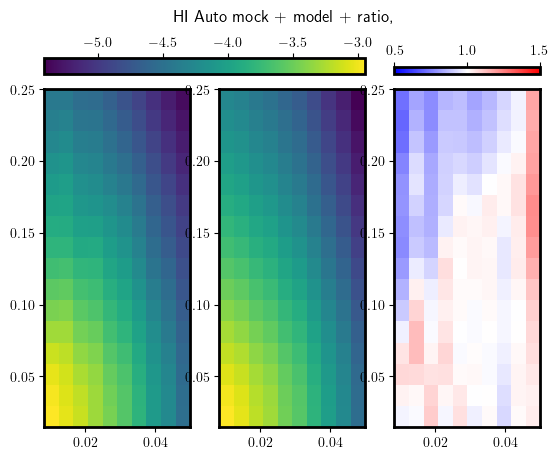

In [42]:
plt.rcParams.update({'font.size':10})
fig = plot_cy_power(
    kperp_bins,
    kpar_bins,
    Pk_HI_2D,
    Pk_HI_2D_model,
    0.5,
    1.5,
)
fig.suptitle('HI Auto mock + model + ratio,')


Text(0.5, 0.98, 'gal Auto mock + model + ratio,')

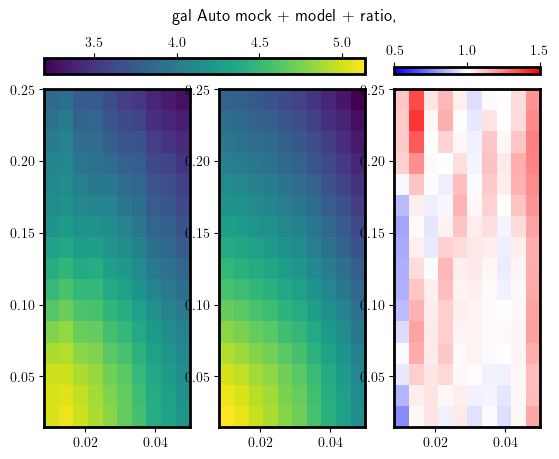

In [43]:
plt.rcParams.update({'font.size':10})
fig = plot_cy_power(
    kperp_bins,
    kpar_bins,
    Pk_gal_2D,
    Pk_gal_2D_model,
    0.5,
    1.5,
)
fig.suptitle('gal Auto mock + model + ratio,')

Text(0.5, 0.98, 'HI x gal mock + model + ratio,')

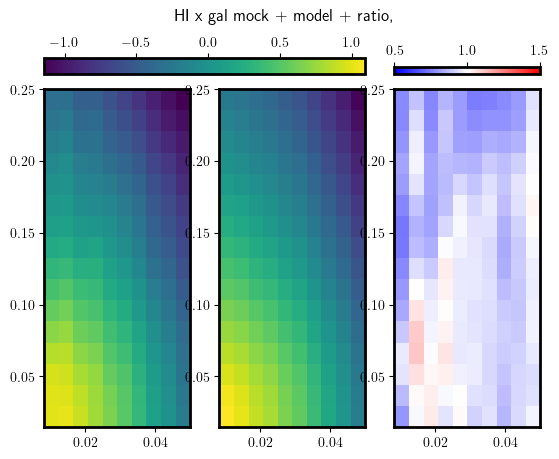

In [44]:
plt.rcParams.update({'font.size':10})
fig = plot_cy_power(
    kperp_bins,
    kpar_bins,
    Pk_HIxgal_2D,
    Pk_HIxgal_2D_model,
    0.5,
    1.5,
)
fig.suptitle('HI x gal mock + model + ratio,')

### Bin and average for the 1D power spectrum

In [45]:
#Model power spectra

Pk_HI_1D_model, keff, nmodes = bin_power_1d(
    (Pk_HI_3D_model)[None],
    kmode,
    k1d_bins,
    k_xy_sel,
)
Pk_HI_1D_model = Pk_HI_1D_model[0]

Pk_HIxgal_1D_model, keff, nmodes = bin_power_1d(
    (Pk_HIxgal_3D_model)[None],
    kmode,
    k1d_bins,
    k_xy_sel,
)
Pk_HIxgal_1D_model = Pk_HIxgal_1D_model[0]

Pk_gal_1D_model, keff, nmodes = bin_power_1d(
    (Pk_gal_3D_model)[None],
    kmode,
    k1d_bins,
    k_xy_sel,
)
Pk_gal_1D_model = Pk_gal_1D_model[0]

In [46]:
# Realization power spectra
Pk_HI_1D_arr = []
Pk_HIxgal_1D_arr = []
Pk_gal_1D_arr = []

for i in range(Nrealizations):
    Pk_HI_1D_i, keff, nmodes = bin_power_1d((p3d_hi[i])[None],
        kmode,
        k1d_bins,
        k_xy_sel,
    )
    Pk_HI_1D_arr.append(Pk_HI_1D_i[0])
    
    Pk_HIxgal_1D_i, keff, nmodes = bin_power_1d((p3d_x[i])[None],
        kmode,
        k1d_bins,
        k_xy_sel,
    )
    Pk_HIxgal_1D_arr.append(Pk_HIxgal_1D_i[0])

    Pk_gal_1D_i, keff, nmodes = bin_power_1d((p3d_gal[i])[None],
        kmode,
        k1d_bins,
        k_xy_sel,
    )
    Pk_gal_1D_arr.append(Pk_gal_1D_i[0])

Pk_HI_1D_arr = np.array(Pk_HI_1D_arr)
Pk_HIxgal_1D_arr = np.array(Pk_HIxgal_1D_arr)
Pk_gal_1D_arr = np.array(Pk_gal_1D_arr)

Pk_HI_1D = Pk_HI_1D_arr.mean(axis=0)
Pk_HIxgal_1D = Pk_HIxgal_1D_arr.mean(axis=0)
Pk_gal_1D = Pk_gal_1D_arr.mean(axis=0)

In [47]:
# Compute covariance!
cov_HI_1D = np.cov(Pk_HI_1D_arr,rowvar=False)
cov_HIxgal_1D = np.cov(Pk_HIxgal_1D_arr,rowvar=False)
cov_gal_1D = np.cov(Pk_gal_1D_arr,rowvar=False)


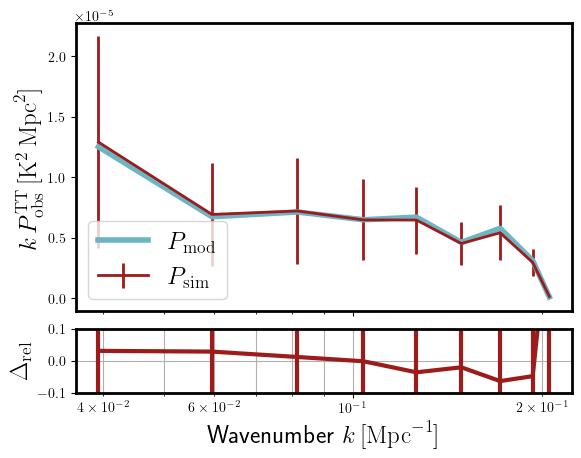

In [48]:

fig, axs = plt.subplots(2, 1, sharex=True, height_ratios=[9, 2])
fig.subplots_adjust(hspace=0.1)

axs[0].errorbar(keff, keff * Pk_HI_1D, yerr=keff * np.sqrt(np.diag(cov_HI_1D)), ls='-', label=r"$P_{\rm sim}$",lw=2)
axs[0].semilogx(keff, keff * Pk_HI_1D_model, label=r"$P_{\rm mod}$",lw=4)

axs[1].errorbar(keff, (Pk_HI_1D - Pk_HI_1D_model)/Pk_HI_1D_model, yerr= np.sqrt(np.diag(cov_HI_1D))/Pk_HI_1D_model, ls='-', label=r"$P_{\rm sim}$")

axs[1].set_ylim(-0.1,0.1)
axs[1].grid(which='both')
axs[1].set_xlabel(r"Wavenumber $k\,[\mathrm{Mpc}^{-1}]$",fontsize=18)
axs[0].set_ylabel(r"$k\,P^{\rm TT}_{\rm obs}\,[\mathrm{K}^2\,\mathrm{Mpc}^{2}]$",fontsize=18)
axs[1].set_ylabel(r"$\Delta_{\rm rel}$",fontsize=18)
axs[0].legend(loc="lower left",fontsize=18)

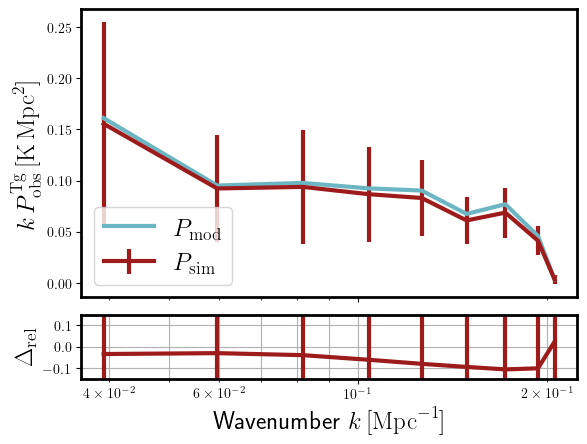

In [50]:

fig, axs = plt.subplots(2, 1, sharex=True, height_ratios=[9, 2])
fig.subplots_adjust(hspace=0.1)

axs[0].errorbar(keff, keff * Pk_HIxgal_1D, yerr=keff * np.sqrt(np.diag(cov_HIxgal_1D)), ls='-', label=r"$P_{\rm sim}$")
axs[0].semilogx(keff, keff * Pk_HIxgal_1D_model, label=r"$P_{\rm mod}$")

axs[1].errorbar(keff, (Pk_HIxgal_1D - Pk_HIxgal_1D_model)/Pk_HIxgal_1D_model, yerr=np.sqrt(np.diag(cov_HIxgal_1D))/Pk_HIxgal_1D_model, ls='-', label=r"$P_{\rm sim}$")

axs[1].set_ylim(-0.15,0.15)
axs[1].grid(which='both')
axs[1].set_xlabel(r"Wavenumber $k\,[\mathrm{Mpc}^{-1}]$",fontsize=18)
axs[0].set_ylabel(r"$k\,P^{\rm Tg}_{\rm obs}\,[\mathrm{K}\,\mathrm{Mpc}^{2}]$",fontsize=18)
axs[1].set_ylabel(r"$\Delta_{\rm rel}$",fontsize=18)
axs[0].legend(loc="lower left",fontsize=18)

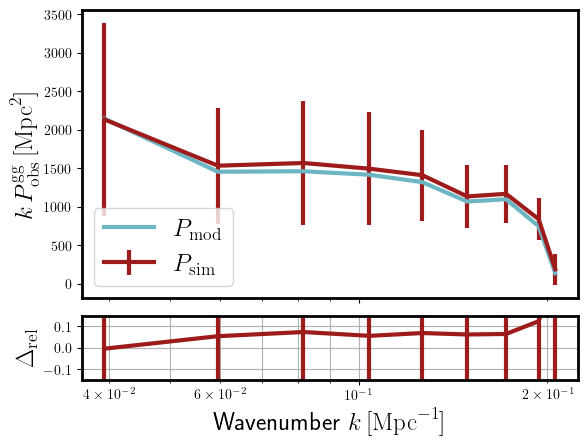

In [51]:

fig, axs = plt.subplots(2, 1, sharex=True, height_ratios=[9, 2])
fig.subplots_adjust(hspace=0.1)

axs[0].errorbar(keff, keff * Pk_gal_1D, yerr=keff * np.sqrt(np.diag(cov_gal_1D)), ls='-', label=r"$P_{\rm sim}$")
axs[0].semilogx(keff, keff * Pk_gal_1D_model, label=r"$P_{\rm mod}$")

axs[1].errorbar(keff, (Pk_gal_1D - Pk_gal_1D_model)/Pk_gal_1D_model, yerr=np.sqrt(np.diag(cov_gal_1D))/Pk_gal_1D_model, ls='-', label=r"$P_{\rm sim}$")

axs[1].set_ylim(-0.15,0.15)
axs[1].grid(which='both')
axs[1].set_xlabel(r"Wavenumber $k\,[\mathrm{Mpc}^{-1}]$",fontsize=18)
axs[0].set_ylabel(r"$k\,P^{\rm gg}_{\rm obs}\,[\mathrm{Mpc}^{2}]$",fontsize=18)
axs[1].set_ylabel(r"$\Delta_{\rm rel}$",fontsize=18)
axs[0].legend(loc="lower left",fontsize=18)

### You want to try different survey configurations to check what's the optimal geometry

But you don't want to rerun all the realizations to obtain a good covariance... rescale it! you have to:
- Compute volume ratios
- Compute a theoretical ratio of the noise power spectrum for the mean frequency of the survey
- Compute the amplitude ratio of the power spectra (e.g., $(D^2\langle Tb\rangle^2)_1/(D^2\langle Tb\rangle^2)_2$)
- Compute the new model power spectrum in the new volume using the same k range than for the previous one

Then, the new covariance will be: $$ \approx {\rm Cov}_{\rm new} = \frac{(D^2\langle Tb\rangle^2)_{\rm new}^2}{(D^2\langle Tb\rangle^2)^2_{\rm old}}\frac{V_{\rm old}}{V_{\rm new}}{\rm Cov}_{\rm old}$$

if the covariance is dominated by the sample variance, or $$ \approx {\rm Cov}_{\rm new} = \frac{\sigma^4_{\rm new}}{\sigma^4_{\rm old}}\frac{V_{\rm old}}{V_{\rm new}}{\rm Cov}_{\rm old}$$ if dominated by noise. 

Note that you may need to explore also different griddings etc... and that's trickier!

In [59]:
#Let's assume this is dominated by noise, and that we go for a redshift range between 0.6 to 0.9
zz = np.linspace(dic['z_min'],dic['z_max'],100)
V_old = np.trapz(Cosmo.differential_comoving_volume(zz),zz)
sigma_old = np.mean(sigma_N(dic,num_pix))


In [60]:
ps_new, dic_new = set_meer21cm(input_dict = dict(z_max=0.9), default_dict = default_dict)

In [61]:
#Let's assume this is dominated by noise, and that we go for a redshift range between 0.6 to 0.9
zz = np.linspace(dic_new['z_min'],dic_new['z_max'],100)
V_new = np.trapz(Cosmo.differential_comoving_volume(zz),zz)
sigma_new = np.mean(sigma_N(dic,num_pix))


In [79]:
Cov_new = cov_HI_1D * sigma_new**4/sigma_old**4 * V_old/V_new

In [70]:
#Get the new power spectrum!
# Apply gridding scheme, tapering, weights and trimming
ps_new.grid_scheme = "cic"
ps_new.taper_function = getattr(windows, dic['window_name'])

num_gal = int(ps_new.survey_volume * dic['ngal'])
ps_new.num_discrete_source = num_gal

#ps.W_HI = np.ones_like(ps.W_HI)
#ps.w_HI = np.ones_like(ps.w_HI)

ps_new.trim_map_to_range()
# ps.trim_gal_to_range() # Returns error: AttributeError: 'PowerSpectrum' object has no attribute '_ra_gal'

ps_new.downres_factor_transverse = 3
ps_new.downres_factor_radial = 6
ps_new.get_enclosing_box()
dndz_box = ps_new.discrete_source_dndz(ps_new._box_voxel_redshift)

ps_new.weights_1 = ps_new.counts_in_box.astype('float')
ps_new.apply_taper_to_field(1, axis=[0, 1, 2])
ps_new.weights_field_2 = dndz_box #* ps.w_HI
ps_new.weights_grid_2 = ((dndz_box>0)*ps_new.counts_in_box).astype('float') # test
ps_new.apply_taper_to_field(2, axis=[0, 1, 2])

ps_new.include_sky_sampling = [True, False]
ps_new.compensate = [True, True]
ps_new.include_beam = [True, False]

# Get a transfer for the beam, pixelization and gridding
beam = ps_new.beam_attenuation()

ps_new.sampling_resol = [
    ps_new.pix_resol_in_mpc,
    ps_new.pix_resol_in_mpc,
    ps_new.los_resol_in_mpc,
]
pix = ps_new.map_sampling()

grid = ps_new.gridding_compensation()

#Transfer square for the model power spectrum, including the mean HI temperature in case you want to use them separately
T2_x = grid**2 * pix * beam
T2_gal = grid**2 
T2_HI = (grid * pix * beam)**2 

Pk_HI_3D_model_new = ps_new.auto_power_tracer_1_model

kperp = ps_new.k_perp
kpar = ps_new.k_para
kmode = ps_new.kmode
kvec = ps_new.k_vec

# and mask those that are beyond your limits (in form of weights)
kperp_limit = 0.05
kpar_limit = 0.2

k_xy_sel = (
    (np.abs(kvec[0])<kperp_limit)[:,None,None] 
    * (np.abs(kvec[1])<kperp_limit)[None,:,None]
    * (np.abs(kvec[2])<kpar_limit)[None,None,:]
)
k_xy_sel[0] = 0.0
k_xy_sel[:,0] = 0.0
k_xy_sel[:,:,0] = 0.0
k_cy_sel = np.ones_like(k_xy_sel)
k_cy_sel[0] = 0.0
k_cy_sel[:,0] = 0.0
k_cy_sel[:,:,0] = 0.0

Pk_HI_1D_model_new, keff, nmodes = bin_power_1d(
    (Pk_HI_3D_model_new)[None],
    kmode,
    k1d_bins,
    k_xy_sel,
)
Pk_HI_1D_model_new = Pk_HI_1D_model_new[0]

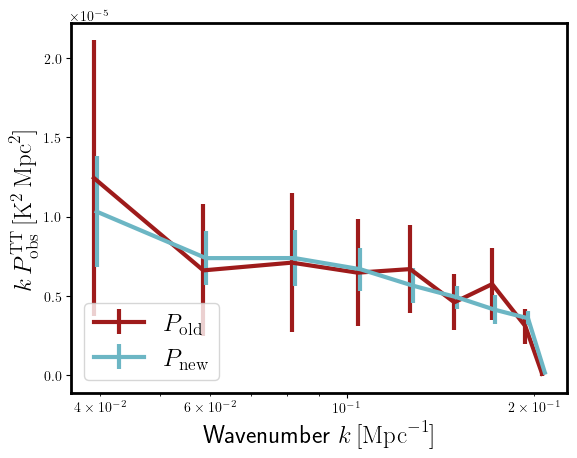

In [82]:

plt.errorbar(keff, keff * Pk_HI_1D_model, yerr=keff * np.sqrt(np.diag(cov_HI_1D)), ls='-', label=r"$P_{\rm old}$")
plt.errorbar(keff*1.01, keff * Pk_HI_1D_model_new, yerr=keff * np.sqrt(np.diag(Cov_new.value)), ls='-', label=r"$P_{\rm new}$")
plt.semilogx()


plt.xlabel(r"Wavenumber $k\,[\mathrm{Mpc}^{-1}]$",fontsize=18)
plt.ylabel(r"$k\,P^{\rm TT}_{\rm obs}\,[\mathrm{K}^2\,\mathrm{Mpc}^{2}]$",fontsize=18)
plt.legend(loc="lower left",fontsize=18)

### You can also use theoretical final power spectra! (not $P_m$)

In [83]:
#Imagine your P_HI(k) (including all theory, RSD, nonlinearities, etc, looks like whatever you write below. I'm using something as a placeholder
from scipy.interpolate import RectBivariateSpline
kk = np.geomspace(1e-4,1e3,100)
mum = np.linspace(-1,1,90)
kkg,mumg = np.meshgrid(kk,mum)
pk = kkg**-2*(1.5+0.5*mumg**2)**2
ipk_hi = RectBivariateSpline(kk,mum,pk.T) #There are better ways to interpolate this..

In [84]:
ps_new_2, dic_new_2 = set_meer21cm(input_dict = dict(z_max=0.9,ipk=ipk_hi), default_dict = default_dict)

In [ ]:
#Get the new power spectrum!
# Apply gridding scheme, tapering, weights and trimming
ps_new_2.grid_scheme = "cic"
ps_new_2.taper_function = getattr(windows, dic['window_name'])

num_gal = int(ps_new_2.survey_volume * dic['ngal'])
ps_new_2.num_discrete_source = num_gal

#ps.W_HI = np.ones_like(ps.W_HI)
#ps.w_HI = np.ones_like(ps.w_HI)

ps_new_2.trim_map_to_range()
# ps.trim_gal_to_range() # Returns error: AttributeError: 'PowerSpectrum' object has no attribute '_ra_gal'

ps_new_2.downres_factor_transverse = 3
ps_new_2.downres_factor_radial = 6
ps_new_2.get_enclosing_box()
dndz_box = ps_new_2.discrete_source_dndz(ps_new_2._box_voxel_redshift)

ps_new_2.weights_1 = ps_new_2.counts_in_box.astype('float')
ps_new_2.apply_taper_to_field(1, axis=[0, 1, 2])
ps_new_2.weights_field_2 = dndz_box #* ps.w_HI
ps_new_2.weights_grid_2 = ((dndz_box>0)*ps_new_2.counts_in_box).astype('float') # test
ps_new_2.apply_taper_to_field(2, axis=[0, 1, 2])

ps_new_2.include_sky_sampling = [True, False]
ps_new_2.compensate = [True, True]
ps_new_2.include_beam = [True, False]

# Get a transfer for the beam, pixelization and gridding
beam = ps_new_2.beam_attenuation()

ps_new_2.sampling_resol = [
    ps_new_2.pix_resol_in_mpc,
    ps_new_2.pix_resol_in_mpc,
    ps_new_2.los_resol_in_mpc,
]
pix = ps_new_2.map_sampling()

grid = ps_new_2.gridding_compensation()

#Transfer square for the model power spectrum, including the mean HI temperature in case you want to use them separately
T2_x = grid**2 * pix * beam
T2_gal = grid**2 
T2_HI = (grid * pix * beam)**2 

Pk_HI_3D_model_new_2 = ps_new_2.auto_power_tracer_1_model

kperp = ps_new_2.k_perp
kpar = ps_new_2.k_para
kmode = ps_new_2.kmode
kvec = ps_new_2.k_vec

# and mask those that are beyond your limits (in form of weights)
kperp_limit = 0.05
kpar_limit = 0.2

k_xy_sel = (
    (np.abs(kvec[0])<kperp_limit)[:,None,None] 
    * (np.abs(kvec[1])<kperp_limit)[None,:,None]
    * (np.abs(kvec[2])<kpar_limit)[None,None,:]
)
k_xy_sel[0] = 0.0
k_xy_sel[:,0] = 0.0
k_xy_sel[:,:,0] = 0.0
k_cy_sel = np.ones_like(k_xy_sel)
k_cy_sel[0] = 0.0
k_cy_sel[:,0] = 0.0
k_cy_sel[:,:,0] = 0.0

Pk_HI_1D_model_new_2, keff, nmodes = bin_power_1d(
    (Pk_HI_3D_model_new_2)[None],
    kmode,
    k1d_bins,
    k_xy_sel,
)
Pk_HI_1D_model_new_2 = Pk_HI_1D_model_new_2[0]

In [29]:
#Get the k and mu values for each entry in the 3D k grid of ps
kperp = ps.k_perp
kpar = ps.k_para
kmode = ps.kmode
kvec = ps.k_vec
mumode = ps.mu_mode

In [32]:
pk_hi_3d = ipk_hi(kmode,mumode,grid=False)

In [34]:
pk_hi_2d = bin_power_cy((pk_hi_3d)[None],
    kperp,
    kpar,
    kperp_bins,
    kpar_bins,
    kweights=k_cy_sel,
)[0]

/home/jlbernal/Code/meer21cm/src/meer21cm/power.py:2054: RuntimeWarning: invalid value encountered in divide
  pscy = pscy / np.sum(weights, 0)[None]


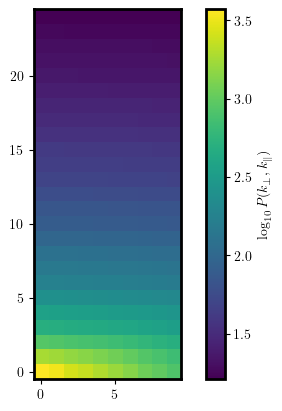

In [47]:
plt.imshow(np.log10(pk_hi_2d).T, origin='lower')
plt.colorbar(label=r'$\log_{10}P(k_\perp,k_\parallel)$')
#axes missing!

In [52]:
pk_hi_1d, keff, nmodes = bin_power_1d(
    (pk_hi_3d)[None],
    kmode,
    k1d_bins,
    k_xy_sel,
)
pk_hi_1d = pk_hi_1d[0]

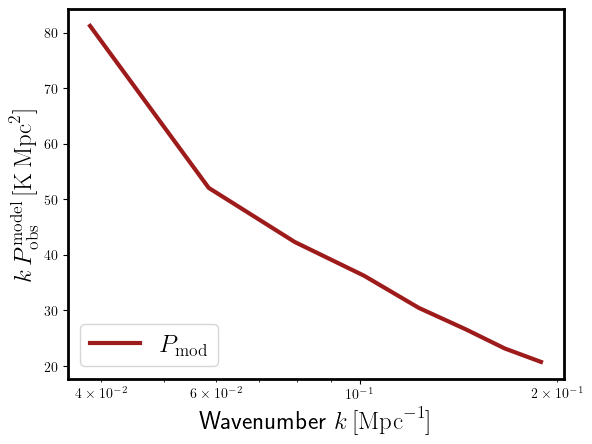

In [61]:


plt.semilogx(keff, keff * pk_hi_1d, label=r"$P_{\rm mod}$")
plt.xlabel(r"Wavenumber $k\,[\mathrm{Mpc}^{-1}]$",fontsize=18)
plt.ylabel(r"$k\,P^{\rm model}_{\rm obs}\,[\mathrm{K}\,\mathrm{Mpc}^{2}]$",fontsize=18)
plt.legend(loc="lower left",fontsize=18)